# Tutorial . Creación de Clase Electromiograma  . 
### Daniel Yedra Cázares, Erin C. McKiernan, Marco Arieli Herrera-Valdez,
### Facultad de Ciencias, UNAM


## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Clase EM ](#EM)

[2.1 Inicialización de la Clase EM](#CO)

[2.1.1 Método 1](#EM1)

[2.2.2 Método 2](#EM2)

[2.2 Derivadas](#Der)

[3. Gráfica de histograma](#hist)

[4. Filtro por Amplitud](#FA)

[5. Varianza del EM en ventanas de tiempo](VVT)

<a id='introduction'></a>
## 1. Introducción

En los tutoriales previos, hemos aprendido a implementar métodos básicos para el manejo de registros, tales como extracción, visualización, filtrado, derivación, entre otros. El objetivo de este tutorial es desarrollar una clase para el procesamiento de Electromiogramas (EMG), en la cual se integrarán las funciones que ya hemos abordado. Este enfoque tiene como finalidad optimizar y facilitar los análisis posteriores de los datos.

In [4]:
pip install statsmodels

  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 3.7 MB/s eta 0:00:00a 0:00:01
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [5]:
%matplotlib inline 

import matplotlib.pyplot as plt
import math
import numpy as np
import scipy.stats as scs 
import scipy as sc
from scipy import signal
from scipy.signal import butter, lfilter, filtfilt,iirnotch 
import wave
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import seaborn as sns
import mplcursors
from scipy.stats import gaussian_kde
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.ticker import MaxNLocator
import pandas as pd


%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 18 
plt.rcParams['axes.titlesize'] = 20 
plt.rcParams['font.size'] = 16 
plt.rcParams['lines.linewidth'] = 1.6 

<a id='EM'></a>
## 2. Clase Electromiograma (EM)

En este paso, procederemos a definir la clase EM, que contará con los atributos fundamentales: archivo, señal y tasa de muestreo. La creación de un objeto de esta clase puede realizarse de dos formas: proporcionando la ruta de acceso al archivo o definiendo directamente la señal y la tasa de muestreo. Los métodos que incluirá la clase abarcan funcionalidades como la visualización del registro, la visualización del histograma, la aplicación de filtros, y la aproximación de las primeras y segundas derivadas, entre otros. Adicionalmente, dependiendo de las necesidades específicas del análisis de la señal de EM, se podrán incorporar métodos adicionales para facilitar estudios más detallados.

In [6]:
class EM:
    def __init__(self, archivo=None, señal=None, tasa_muestra=None):
        if archivo:
            # Si se pasa un archivo, cargarlo
            self.cargar_archivo(archivo)
        elif señal is not None and tasa_muestra is not None:
            # Si se pasa directamente la señal y la frecuencia de muestreo
            self.señal= señal
            self.tasa_muestra = tasa_muestra
            self.vector_tiempo = self.crear_vector_tiempo()
        else:
            raise ValueError("Debes proporcionar un archivo o la señal y frecuencia de muestreo.")
    
    def cargar_archivo(self, archivo):
        with wave.open(archivo, 'rb') as muestra:
            # Extraer el número de canales, la tasa de muestreo y los datos
            num_canales =  muestra.getnchannels()  # Número de canales
            N = muestra.getnframes()  # Número de frames
            self.tasa_muestra = muestra.getframerate()  # Tasa de muestreo

            # Extraer datos de la grabación .wav
            dstr = muestra.readframes(N * num_canales)
            self.señal = np.frombuffer(dstr, np.int16) #Lo que era waveData antes

            # Crear el vector de tiempo basado en la señal y la frecuencia de muestreo
            self.vector_tiempo = self.crear_vector_tiempo()

            # Imprimir información relevante
            print(f'El registro tiene {num_canales} canal(es).')
            print(f'La frecuencia de muestreo de la grabación es {self.tasa_muestra} Hz.')

    def crear_vector_tiempo(self):
        return np.linspace(0, len(self.señal) / self.tasa_muestra, num=len(self.señal))
    def visualizar(self,xmin,xmax):
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))  # Tamaño más compacto y elegante
        
        # Graficar los datos
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')

        # Añadir título y etiquetas
        ax1.set_title('Datos del Registro', fontsize=22, fontweight='bold', color='darkblue')  # Título en negrita y azul
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')  # Eje X con color
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')  # Eje Y con color

        # Ajustar los límites según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')  # Mejorar tamaño y color de los ticks

        # Agregar una cuadrícula (grid) con un estilo suave
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')

        # Mostrar leyenda con los límites del eje x
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        # Mostrar la gráfica
        plt.tight_layout()  # Ajustar el diseño automáticamente para que no se corten los elementos
        plt.show()
        
    def Señal_filtrada_Bandpass(self,low_cutoff,high_cutoff):

        b, a = butter(2, [low_cutoff / (self.tasa_muestra / 2), high_cutoff / (self.tasa_muestra / 2)], btype='bandpass')
        Señal_bandpass = filtfilt(b, a, self.señal)
    
        return Señal_bandpass
        
    def visualizar_filtrada(self, xmin, xmax, low_cutoff, high_cutoff):
        # Obtener la señal filtrada
        señal_filtrada = self.Señal_filtrada_Bandpass(low_cutoff, high_cutoff)
        
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Graficar la señal cruda (con opacidad reducida) y la señal filtrada
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM Cruda', alpha=0.5)
        ax1.plot(self.vector_tiempo, señal_filtrada, color='darkred', linewidth=2, label='Señal EM Filtrada')
        
        # Añadir título y etiquetas
        ax1.set_title('Datos Crudos vs. Filtrado usando BP', fontsize=22, fontweight='bold', color='darkblue')
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')

        # Ajustar los límites del eje x según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        plt.tight_layout()
        plt.show()
        
    def aproxDer(self): 
        V = np.array(self.señal)  # Convertimos los datos a un array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 2:
            return np.zeros(N)  # Si hay menos de 2 elementos, no se puede derivar
    
        derivadas = np.zeros(N)  # Inicializamos un array del mismo tamaño
    
        if N > 2:
            # Derivada central para los puntos intermedios
            derivadas[1:-1] = (V[2:] - V[:-2]) / (2 * DT)
    
        # Derivada hacia adelante en el primer punto
        derivadas[0] = (V[1] - V[0]) / DT
    
        # Derivada hacia atrás en el último punto
        derivadas[-1] = (V[-1] - V[-2]) / DT

        return derivadas
        
    def aprox_2Der(self):

        V = np.array(self.señal)  # Convertir a array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 3:
            return np.zeros(N)  # No es posible calcular la segunda derivada con menos de 3 puntos
    
        derivadas2 = np.zeros(N)
    
        # Derivada central para puntos intermedios:
        # f''(x) ≈ (f(x+DT) - 2 f(x) + f(x-DT)) / DT²
        derivadas2[1:-1] = (V[2:] - 2 * V[1:-1] + V[:-2]) / (DT ** 2)
    
        # Para el primer y último punto usamos aproximaciones hacia adelante y hacia atrás:
        derivadas2[0] = (V[2] - 2 * V[1] + V[0]) / (DT ** 2)
        derivadas2[-1] = (V[-1] - 2 * V[-2] + V[-3]) / (DT ** 2)
    
        return derivadas2
    
    def visualizar_histograma(self, bins=50, color='skyblue', alpha=0.7, mostrar_kde=False):

        plt.figure(figsize=(10, 6))

        # Graficar el histograma con la opción de mostrar o no la KDE
        sns.histplot(self.señal, bins=bins, color=color, alpha=alpha, kde=mostrar_kde)

        plt.title('Histograma de la Señal', fontsize=22)
        plt.xlabel('Voltaje ($\mu$V)', fontsize=16)
        plt.ylabel('Frecuencia', fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')

        plt.tight_layout()
        plt.show()
        
    def Descrip_est(self):
        # Usar scipy.stats.describe para obtener el resumen estadístico de la señal
        stats = scs.describe(self.señal)
        
        # Desglosar los valores obtenidos
        nobs = stats.nobs          # Número de observaciones
        minmax = stats.minmax      # Mínimo y máximo de la señal
        mean = float(stats.mean)   # Convertir a tipo float
        variance = float(stats.variance)  # Convertir a tipo float
        skewness = float(stats.skewness)  # Convertir a tipo float
        kurtosis = float(stats.kurtosis)  # Convertir a tipo float
        
        # Mostrar los resultados de manera limpia
        print(f"Resumen Estadístico de la Señal EM:")
        print(f"  - Número de observaciones: {nobs}")
        print(f"  - Mínimo y máximo: {minmax}")
        print(f"  - Media: {mean:.4f}")  # Mostrar con 4 decimales
        print(f"  - Varianza: {variance:.4f}")  # Mostrar con 4 decimales
        print(f"  - Asimetría: {skewness:.4f}")  # Mostrar con 4 decimales
        print(f"  - Curtosis: {kurtosis:.4f}")  # Mostrar con 4 decimales

    # Método para discriminar por amplitud
    def discriminar_por_amplitud(self, umbral=400):
        # Crear un DataFrame con la señal y su tiempo
        df = pd.DataFrame({'Tiempo': self.vector_tiempo, 'Amplitud': self.señal})
        
        # Filtrar el DataFrame por amplitudes mayores al umbral
        filtered = df[df["Amplitud"] > umbral]
        
        # Mostrar la gráfica de las amplitudes mayores al umbral
        plt.figure(figsize=(12, 6))
        plt.plot(filtered['Tiempo'], filtered['Amplitud'], color='dodgerblue', linewidth=1.5)
        plt.title(f'Señal Filtrada por Amplitud > {umbral} $\mu$V', fontsize=22, fontweight='bold', color='darkblue')
        plt.xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        plt.ylabel('Amplitud ($\mu$V)', fontsize=16, color='darkgreen')
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()
        
        return filtered  # Devuelve el DataFrame filtrado

    # Método para dividir la señal en ventanas de tiempo
    def ventana_1_canal(self, x, npoints):
        single_chan_wind = []
        tot_points = len(x)  # Número total de puntos en la serie
        L = npoints

        nwind = tot_points // npoints  # Número de ventanas

        for h in range(0, nwind):
            t = x[h * L:L * (1 + h)]  # Separar en ventanas
            single_chan_wind.append(t)  # Guardar las ventanas

        return single_chan_wind

    # Método para calcular la varianza en cada ventana de tiempo
    def varianza_ventana_1_canal(self, x, npoints):
        tot_points = len(x)  # Número total de puntos
        nwind = tot_points // npoints  # Número de ventanas
        wind_x = self.ventana_1_canal(x, npoints)  # Llamada a la función para obtener las ventanas
        
        # Calcular la varianza de cada ventana
        v_single_chan_wind = [np.var(wind_x[w]) for w in range(0, nwind)]
        
        return v_single_chan_wind

    # Método para visualizar la varianza de la señal en ventanas de tiempo
    def visualizar_varianza(self, npoints=50000):
        # Normalizar la varianza para una mejor visualización
        varianza = self.varianza_ventana_1_canal(self.señal, npoints)
        varianza_normalizada = np.array(varianza) / max(varianza)

        # Crear la figura
        plt.figure(figsize=(20, 5), dpi=100)
        plt.title('Varianza del EM en ventanas de tiempo')
        plt.xlabel('Ventana de tiempo')
        plt.ylabel('Varianza')

        # Graficar la varianza normalizada
        plt.plot(varianza_normalizada)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()

Ahora vamos a mostrar las 2 formas de creación de la clase, además de como aplicar algunos métodos

<a id='CO'></a>
### Creación de un Objeto de la Clase EM

<a id='EM1'></a>
#### Primer método

In [7]:
#Ejemplo de un EMG con la ruta de acceso 
EMG = EM(archivo="/Users/danielyedra/Music/Spike Recorder/RegistroPulgar_Daniel.wav")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {EMG.señal}")
print(f"Tiempo de la señal: {EMG.vector_tiempo[-1]} segundos")

#Método que nos da una descripción estadistica simple
EMG.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 44100 Hz.
Señal de la muestra: [-46 -38 -34 ...   3   1  -5]
Tiempo de la señal: 61.26698412698413 segundos
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 2701874
  - Mínimo y máximo: (np.int16(-5874), np.int16(5077))
  - Media: -0.0134
  - Varianza: 296885.0955
  - Asimetría: 0.1671
  - Curtosis: 2.4214


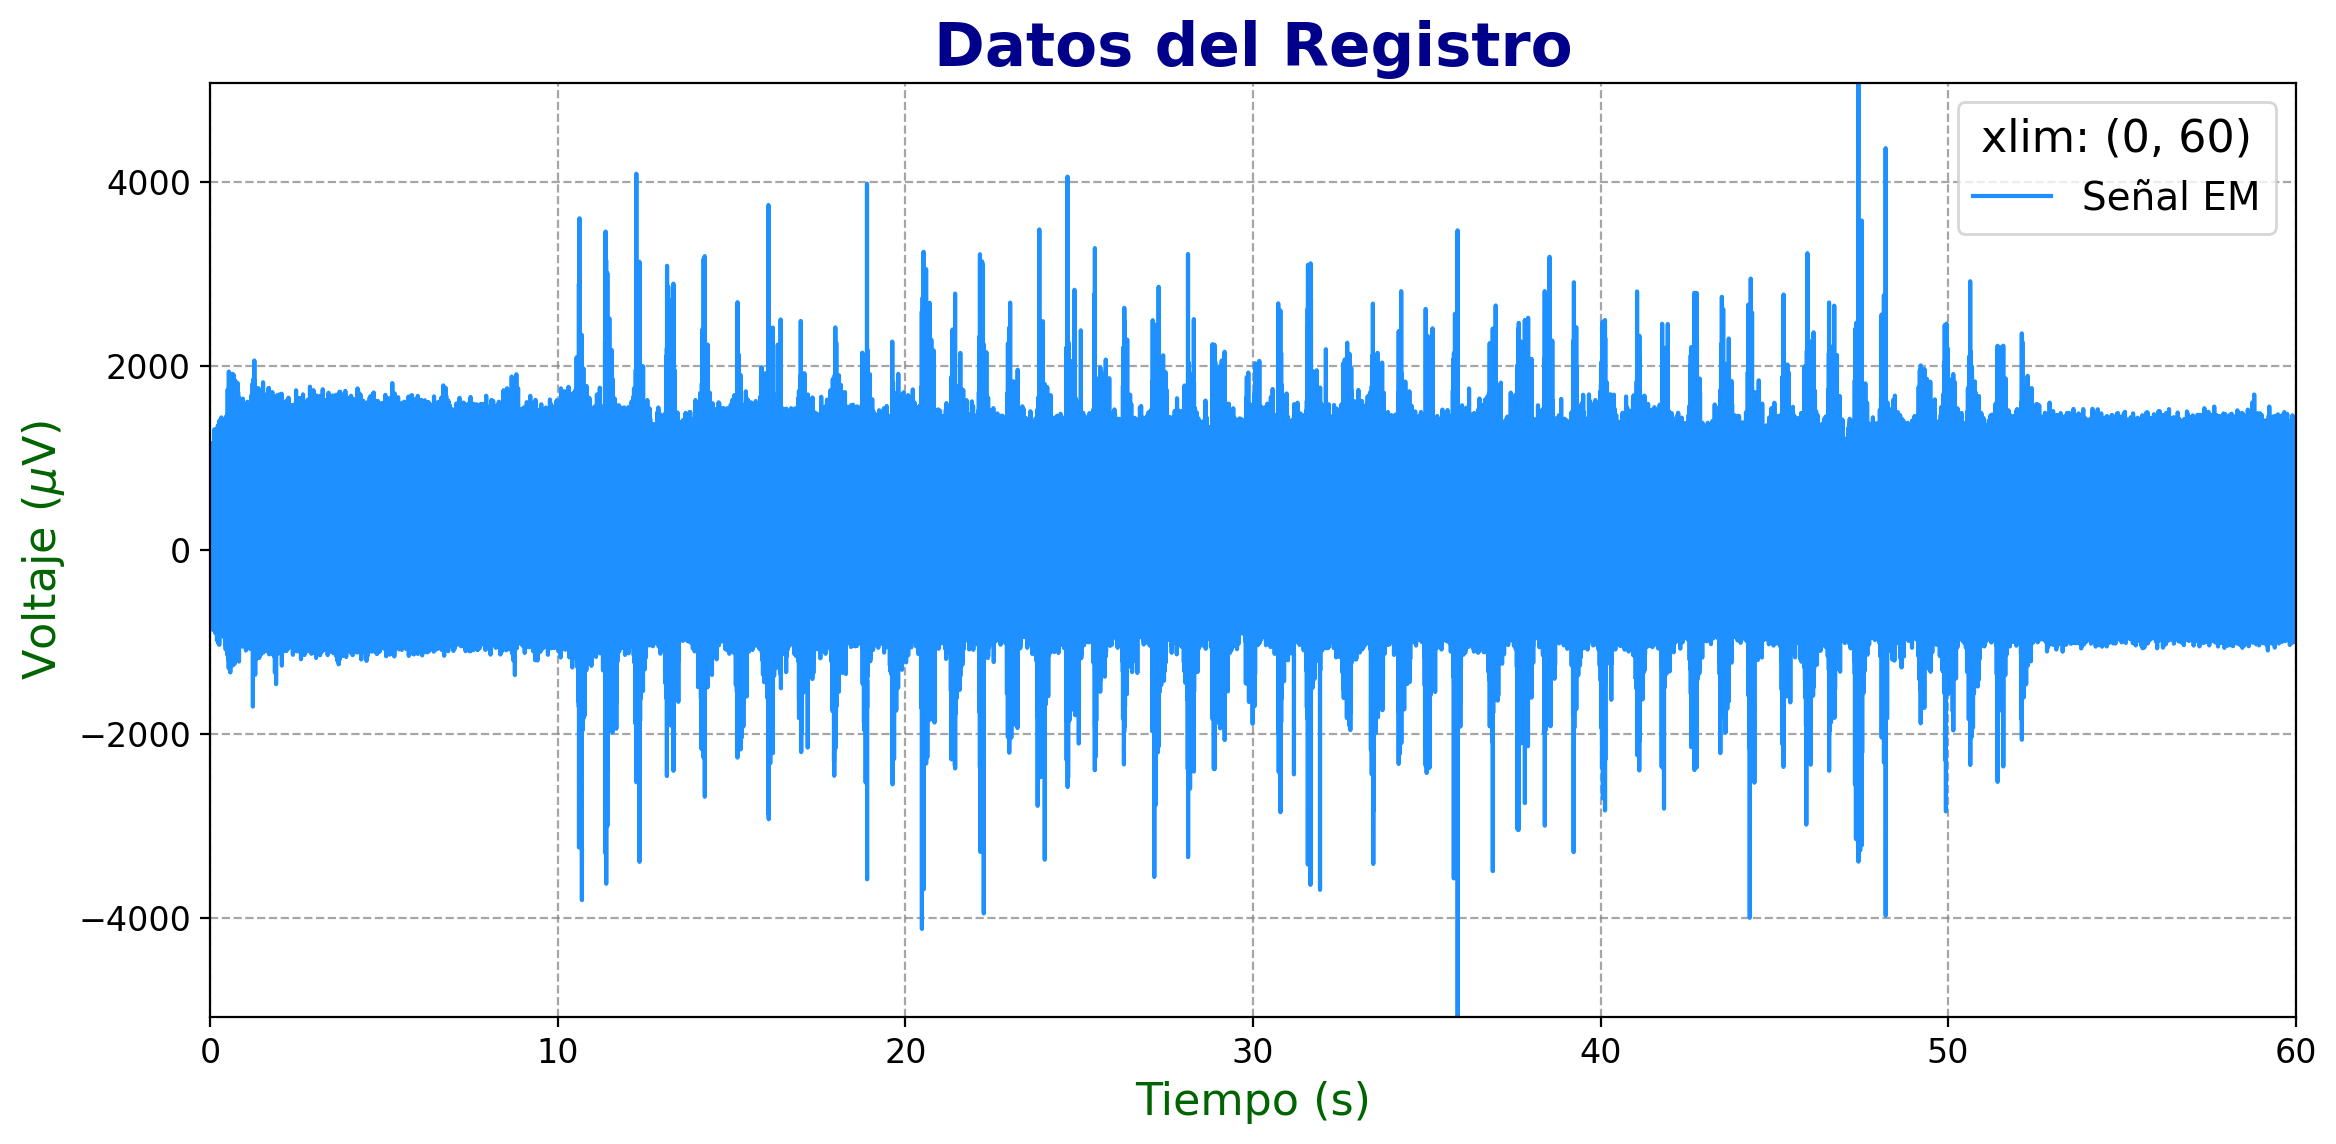

In [8]:
#Visualización del registro
EMG.visualizar(0,60)

Para mostrar el otra forma de crear un objeto vamos a aplicar el método que nos regresa la señal con el filtro de BandPass

<a id='EM2'></a>
#### Segundo método

In [7]:
#Aplicamos el Filtro BandPass de 100 hasta 1000
Señal_Filtrada=EMG.Señal_filtrada_Bandpass(100,1000)

#Definimos el nuevo objeto de EM con la señal filtrada, con la misma tasa de muestra
EMG_Filtrada = EM(señal=Señal_Filtrada , tasa_muestra=EMG.tasa_muestra)

Es importante destacar que contamos con dos métodos de visualización: el primero muestra el registro original tal cual, mientras que el segundo presenta tanto el registro original como el filtrado, permitiendo así una comparación directa entre ambos.

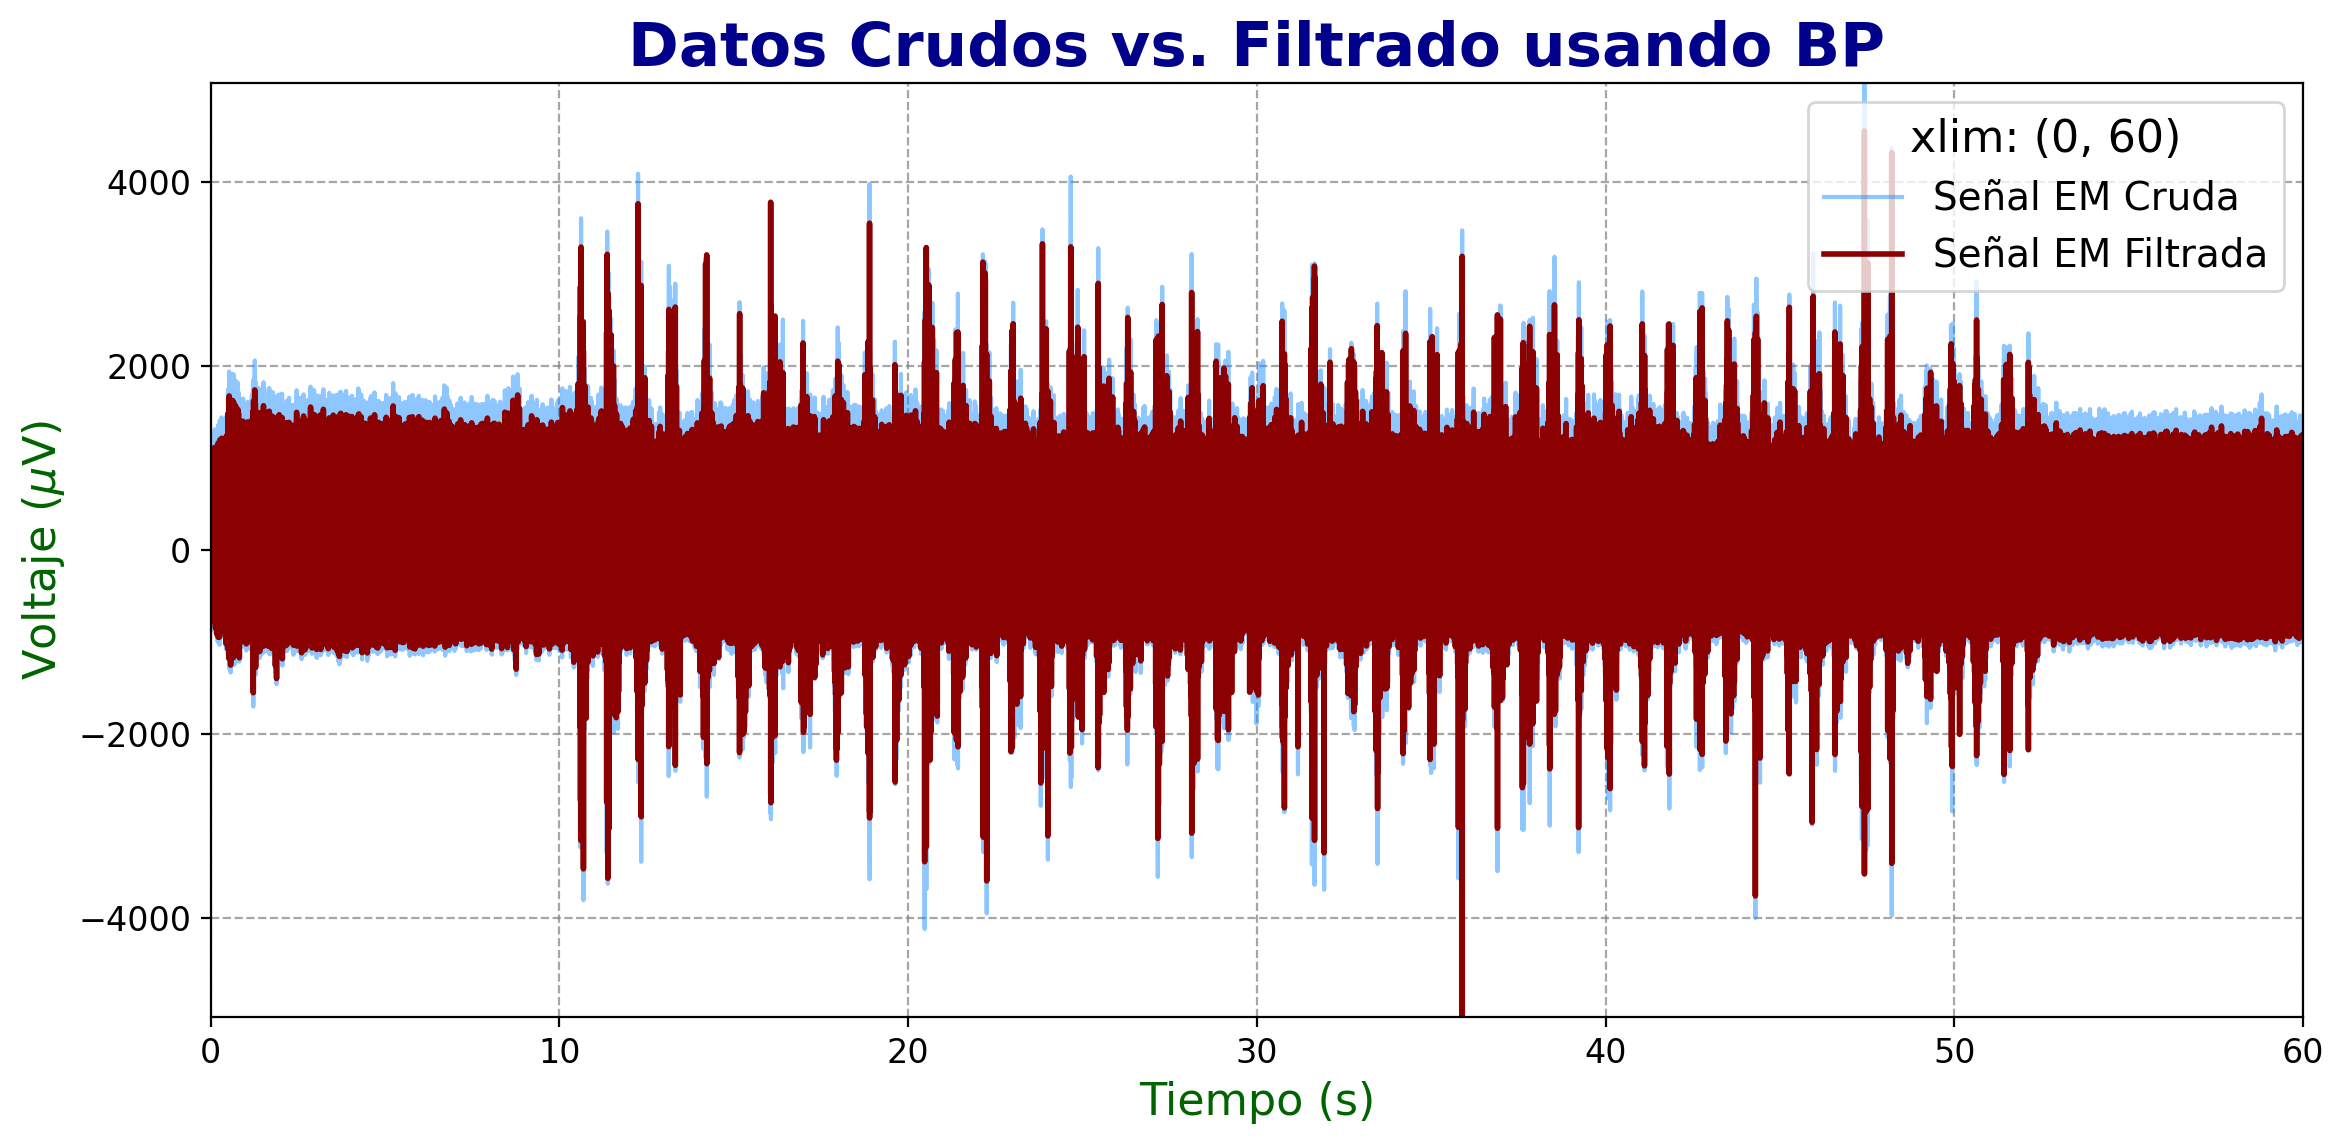

In [8]:
EMG.visualizar_filtrada(0, 60, 100, 1000)

<a id='Der'></a>
### Derivadas
Otros métodos clave para análisis posteriores incluyen la primera y segunda derivada. Estos métodos proporcionan versiones modificadas de la señal original, lo que permite un análisis más detallado de sus características.

In [9]:
#Señal aplicando la primer derivada
Señal_1=EMG_Filtrada.aproxDer()

#Definimos el nuevo objeto de EM con la primer derivada y con la misma tasa de muestra
Primer_Derivada = EM(señal=Señal_1 , tasa_muestra=EMG_Filtrada.tasa_muestra)

#Señal aplicando la segunda derivada
Señal_2=EMG_Filtrada.aprox_2Der()

#Definimos el nuevo objeto de EM con la segunda derivada y con la misma tasa de muestra
Segunda_Derivada=EM(señal=Señal_2 , tasa_muestra=EMG_Filtrada.tasa_muestra)

<a id='hist'></a>
### Histogramas

Para generar el histograma de frecuencias de un objeto de la clase EM ocupamos el método visualizar_histograma el 

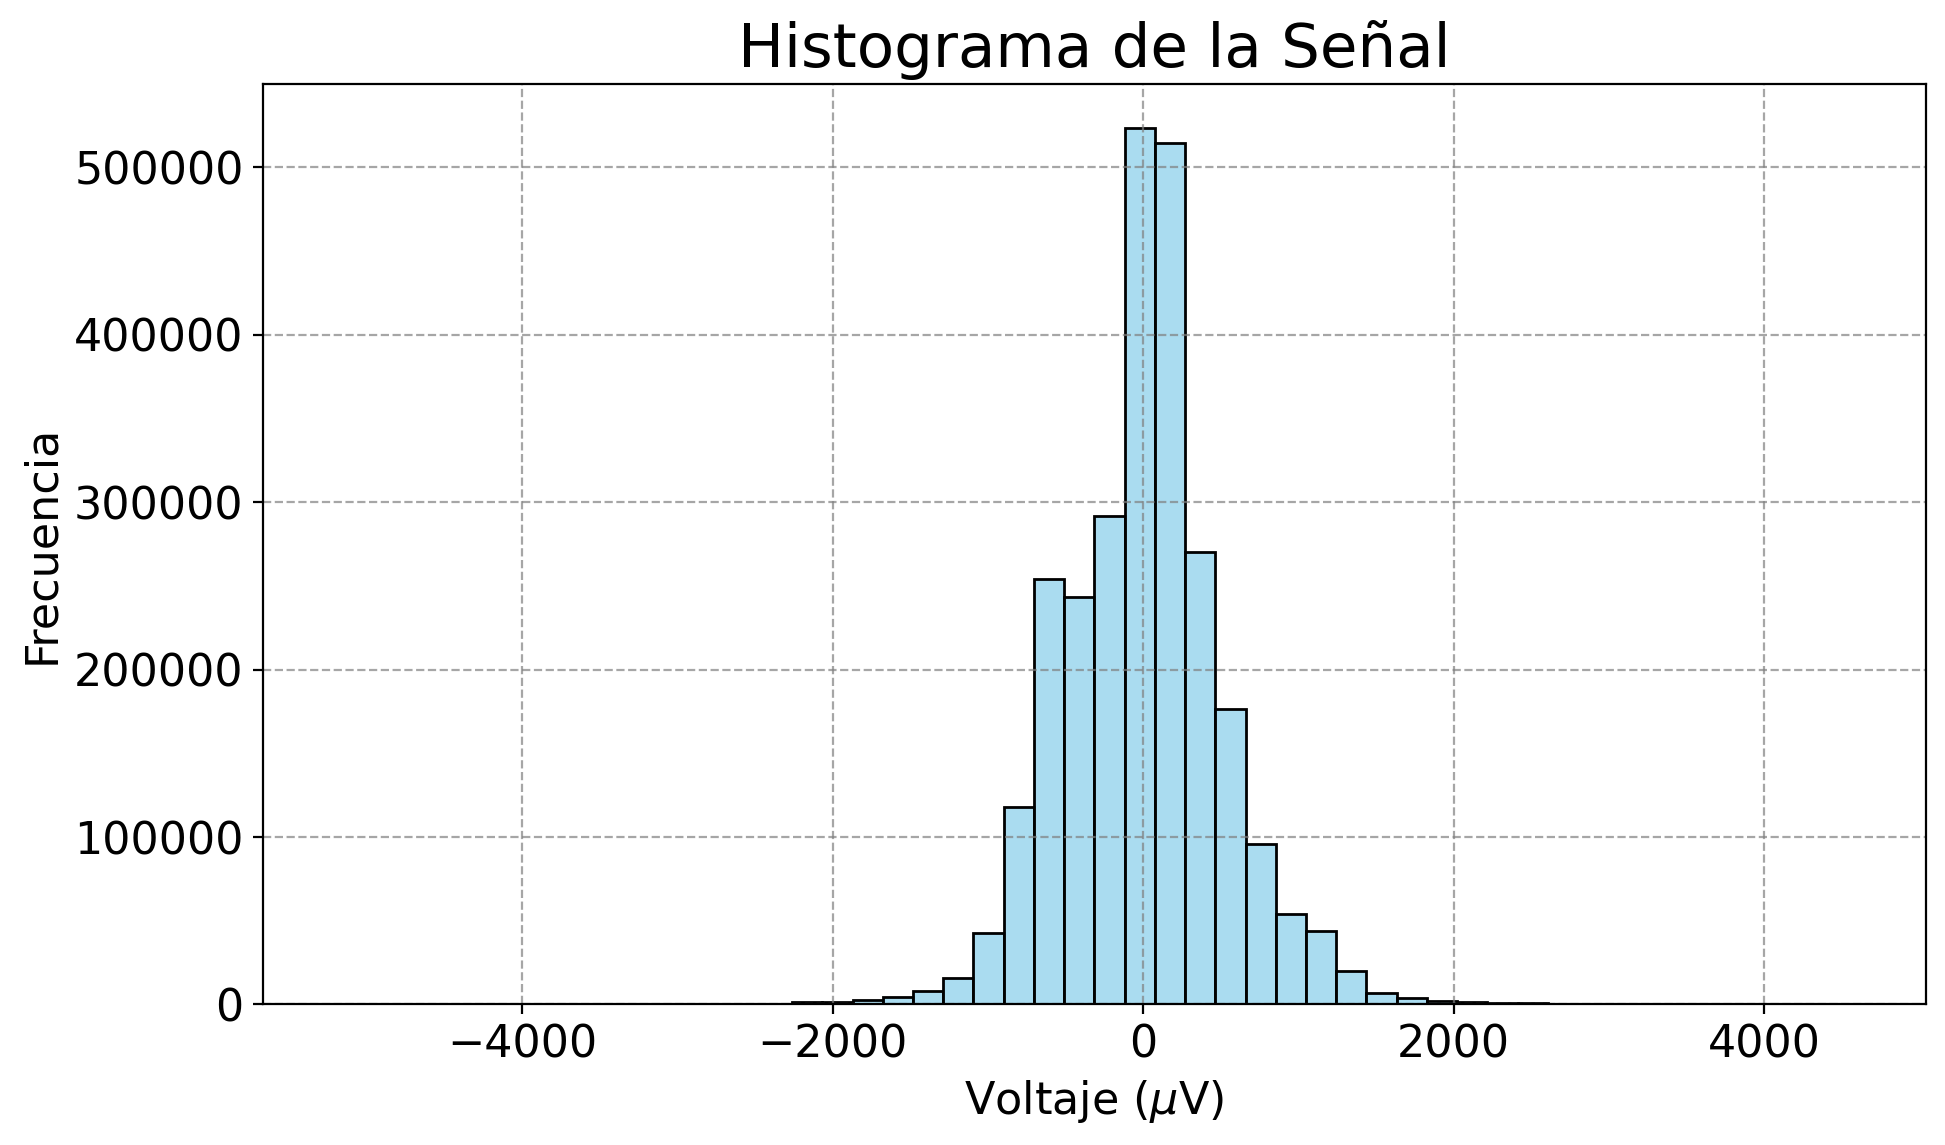

In [10]:
EMG_Filtrada.visualizar_histograma()

<a id='FA'></a>
### Filtro por Aplitud

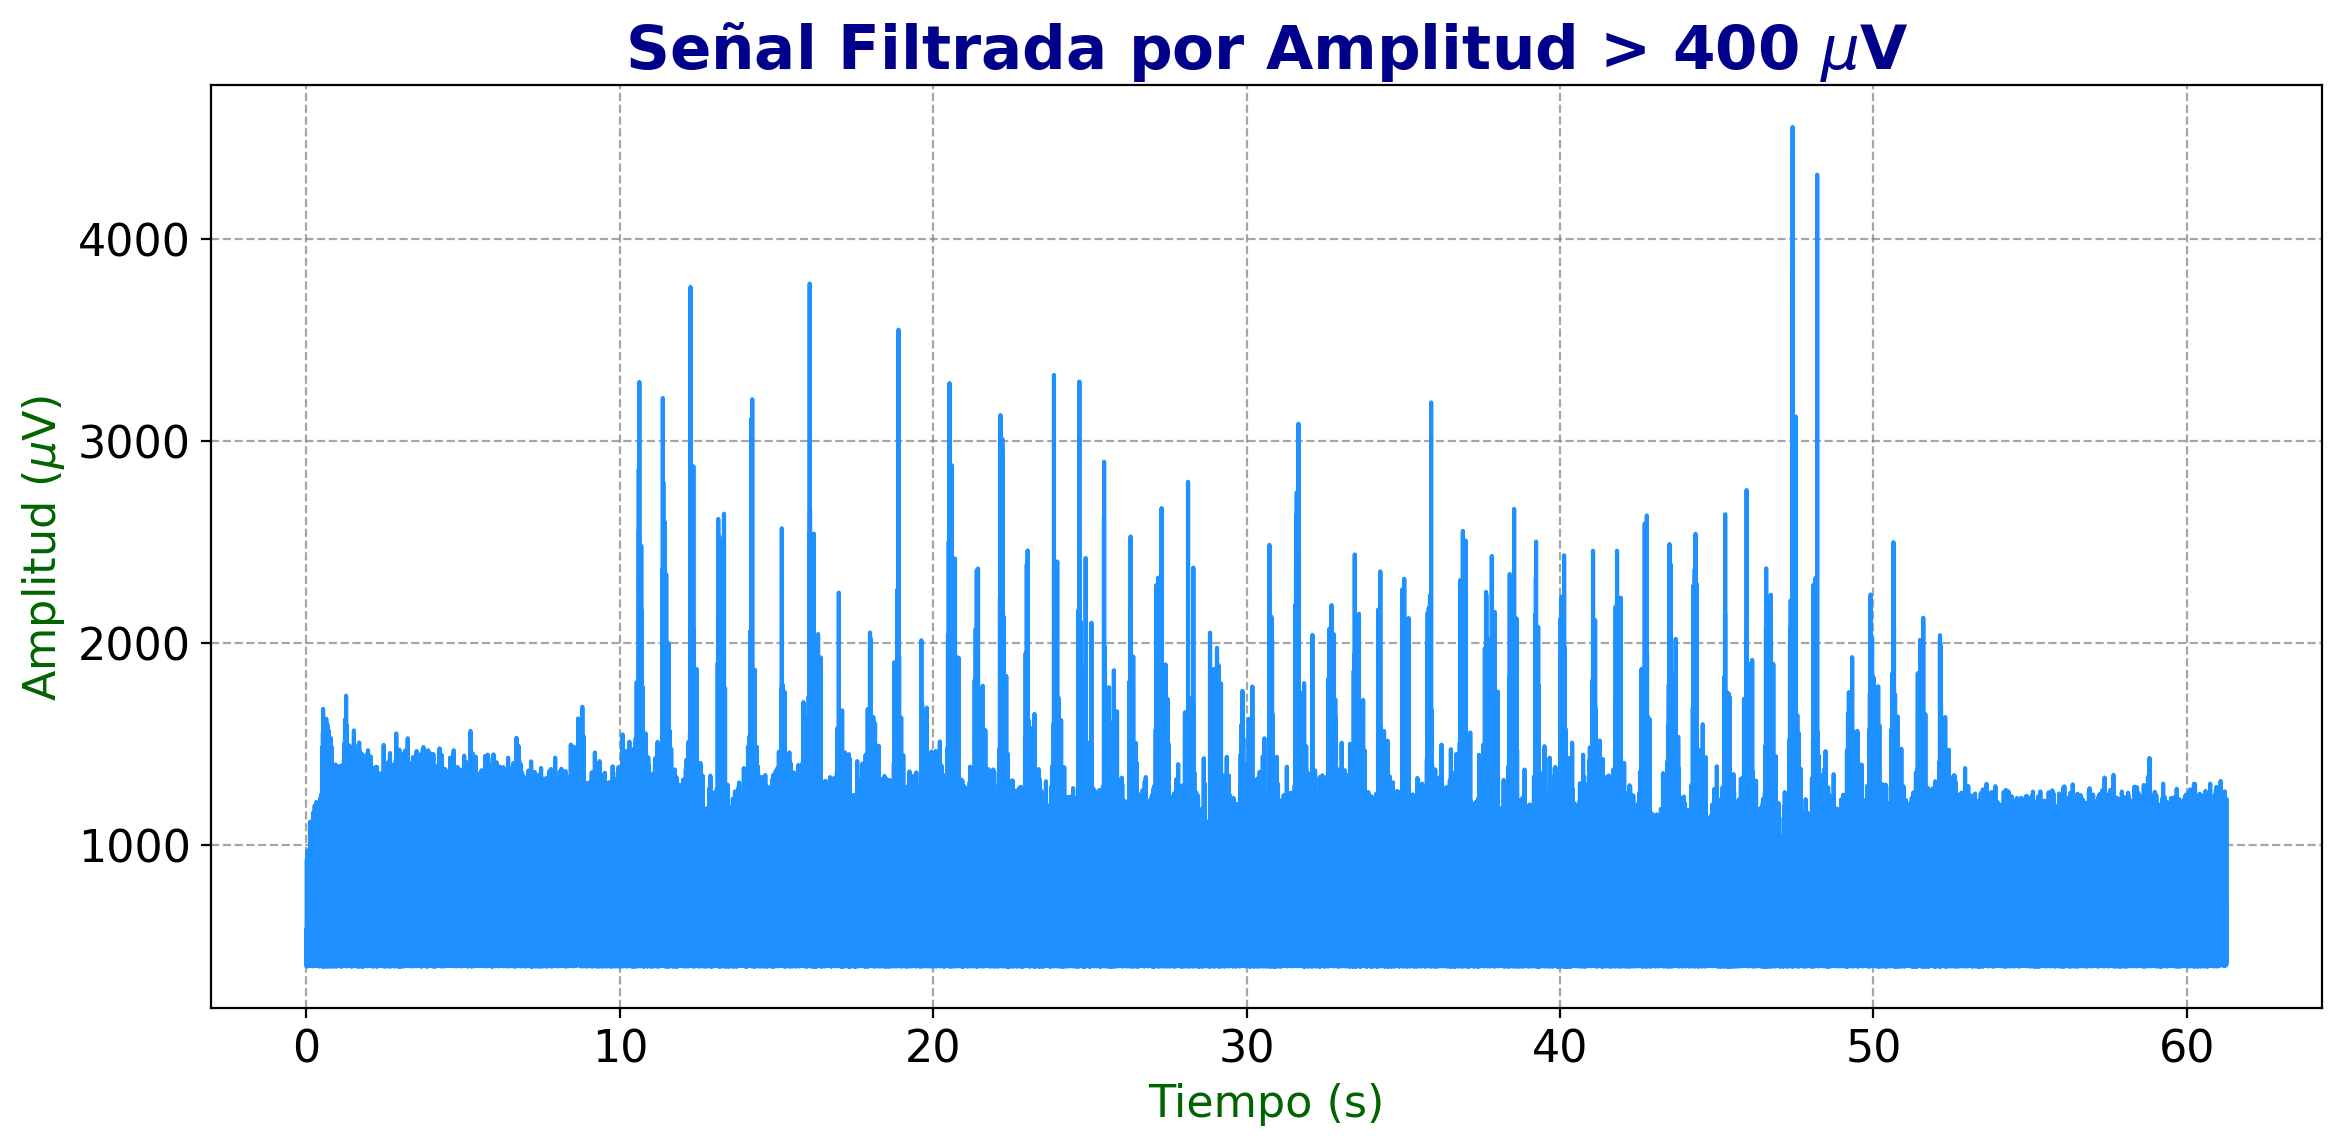

In [11]:
#Amplitudes mayores a 400 microvolts
Filtro_Amplitud=EMG_Filtrada.discriminar_por_amplitud(umbral=400)

<a id='FA'></a>
### Varianza por Ventanas de Tiempo

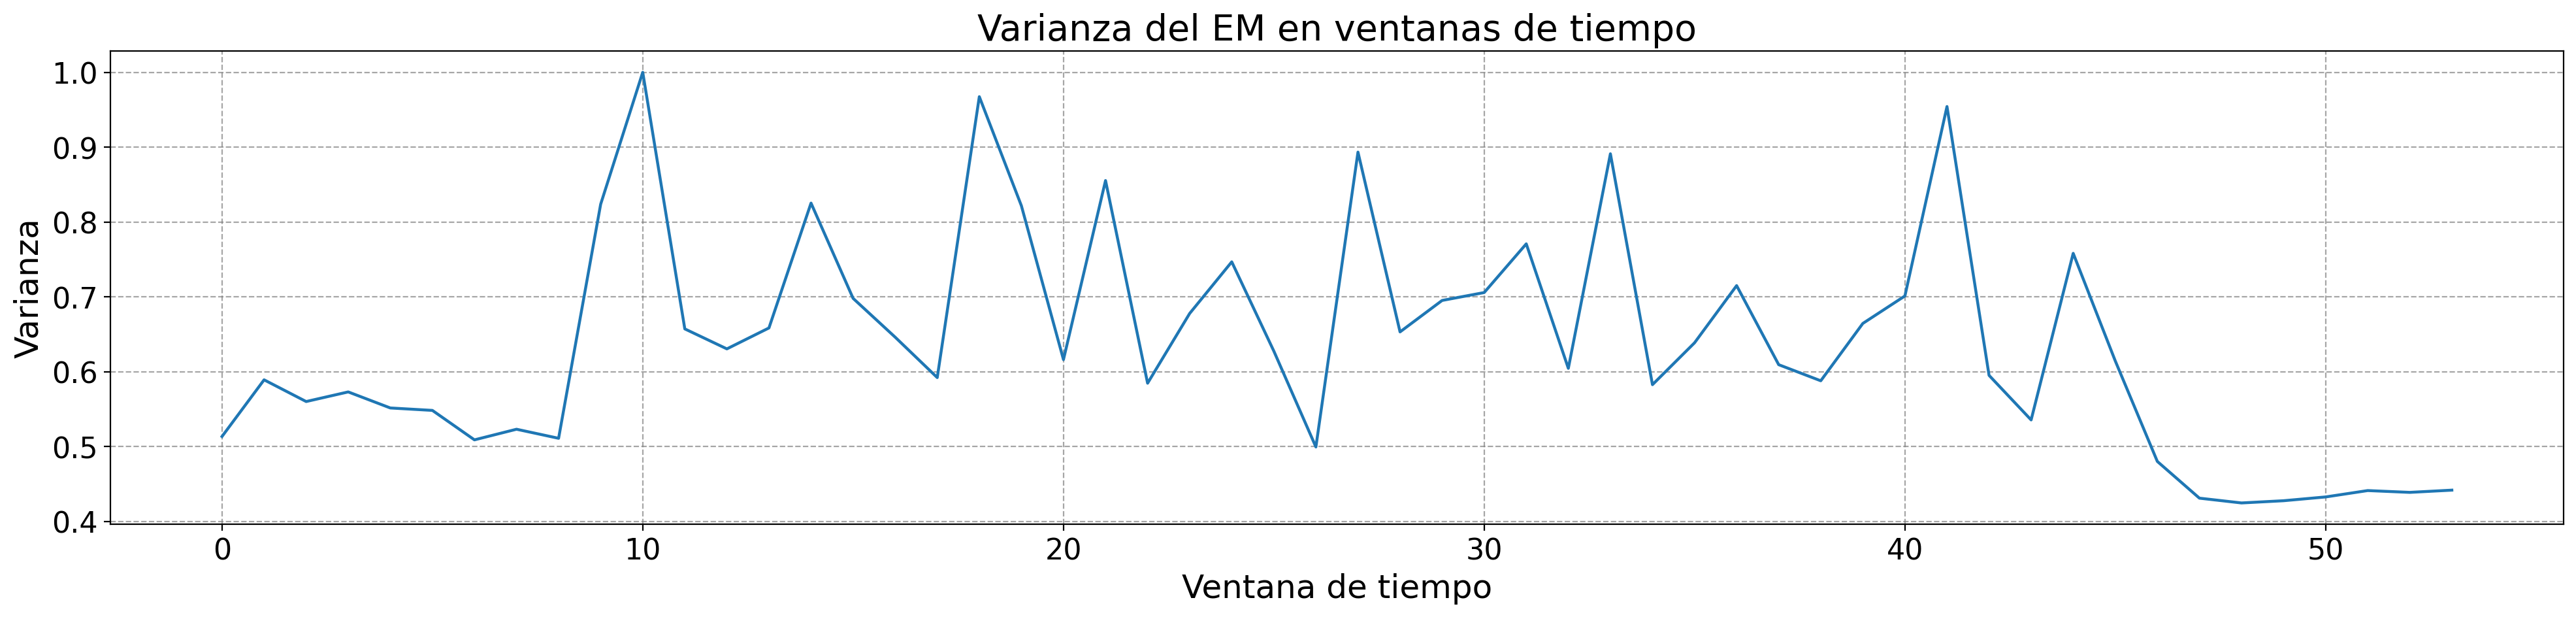

In [12]:
EMG_Filtrada.visualizar_varianza(npoints=50000)

In [9]:
#Ejemplo de un EMG con la ruta de acceso 
EMG_Ej = EM(archivo="/Users/danielyedra/Desktop/Electro_fisio/electrophys/EMG/EMGbasics/data/S1_EMG_bicep_flexExt.wav")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {EMG_Ej.señal}")
print(f"Tiempo de la señal: {EMG_Ej.vector_tiempo[-1]} segundos")

#Método que nos da una descripción estadistica simple
EMG_Ej.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 44100 Hz.
Señal de la muestra: [ 280  999  941 ... 1083 1410 1146]
Tiempo de la señal: 42.09727891156463 segundos
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 1856490
  - Mínimo y máximo: (np.int16(-24933), np.int16(22683))
  - Media: 3.3718
  - Varianza: 29420022.2233
  - Asimetría: 0.1361
  - Curtosis: 0.8129


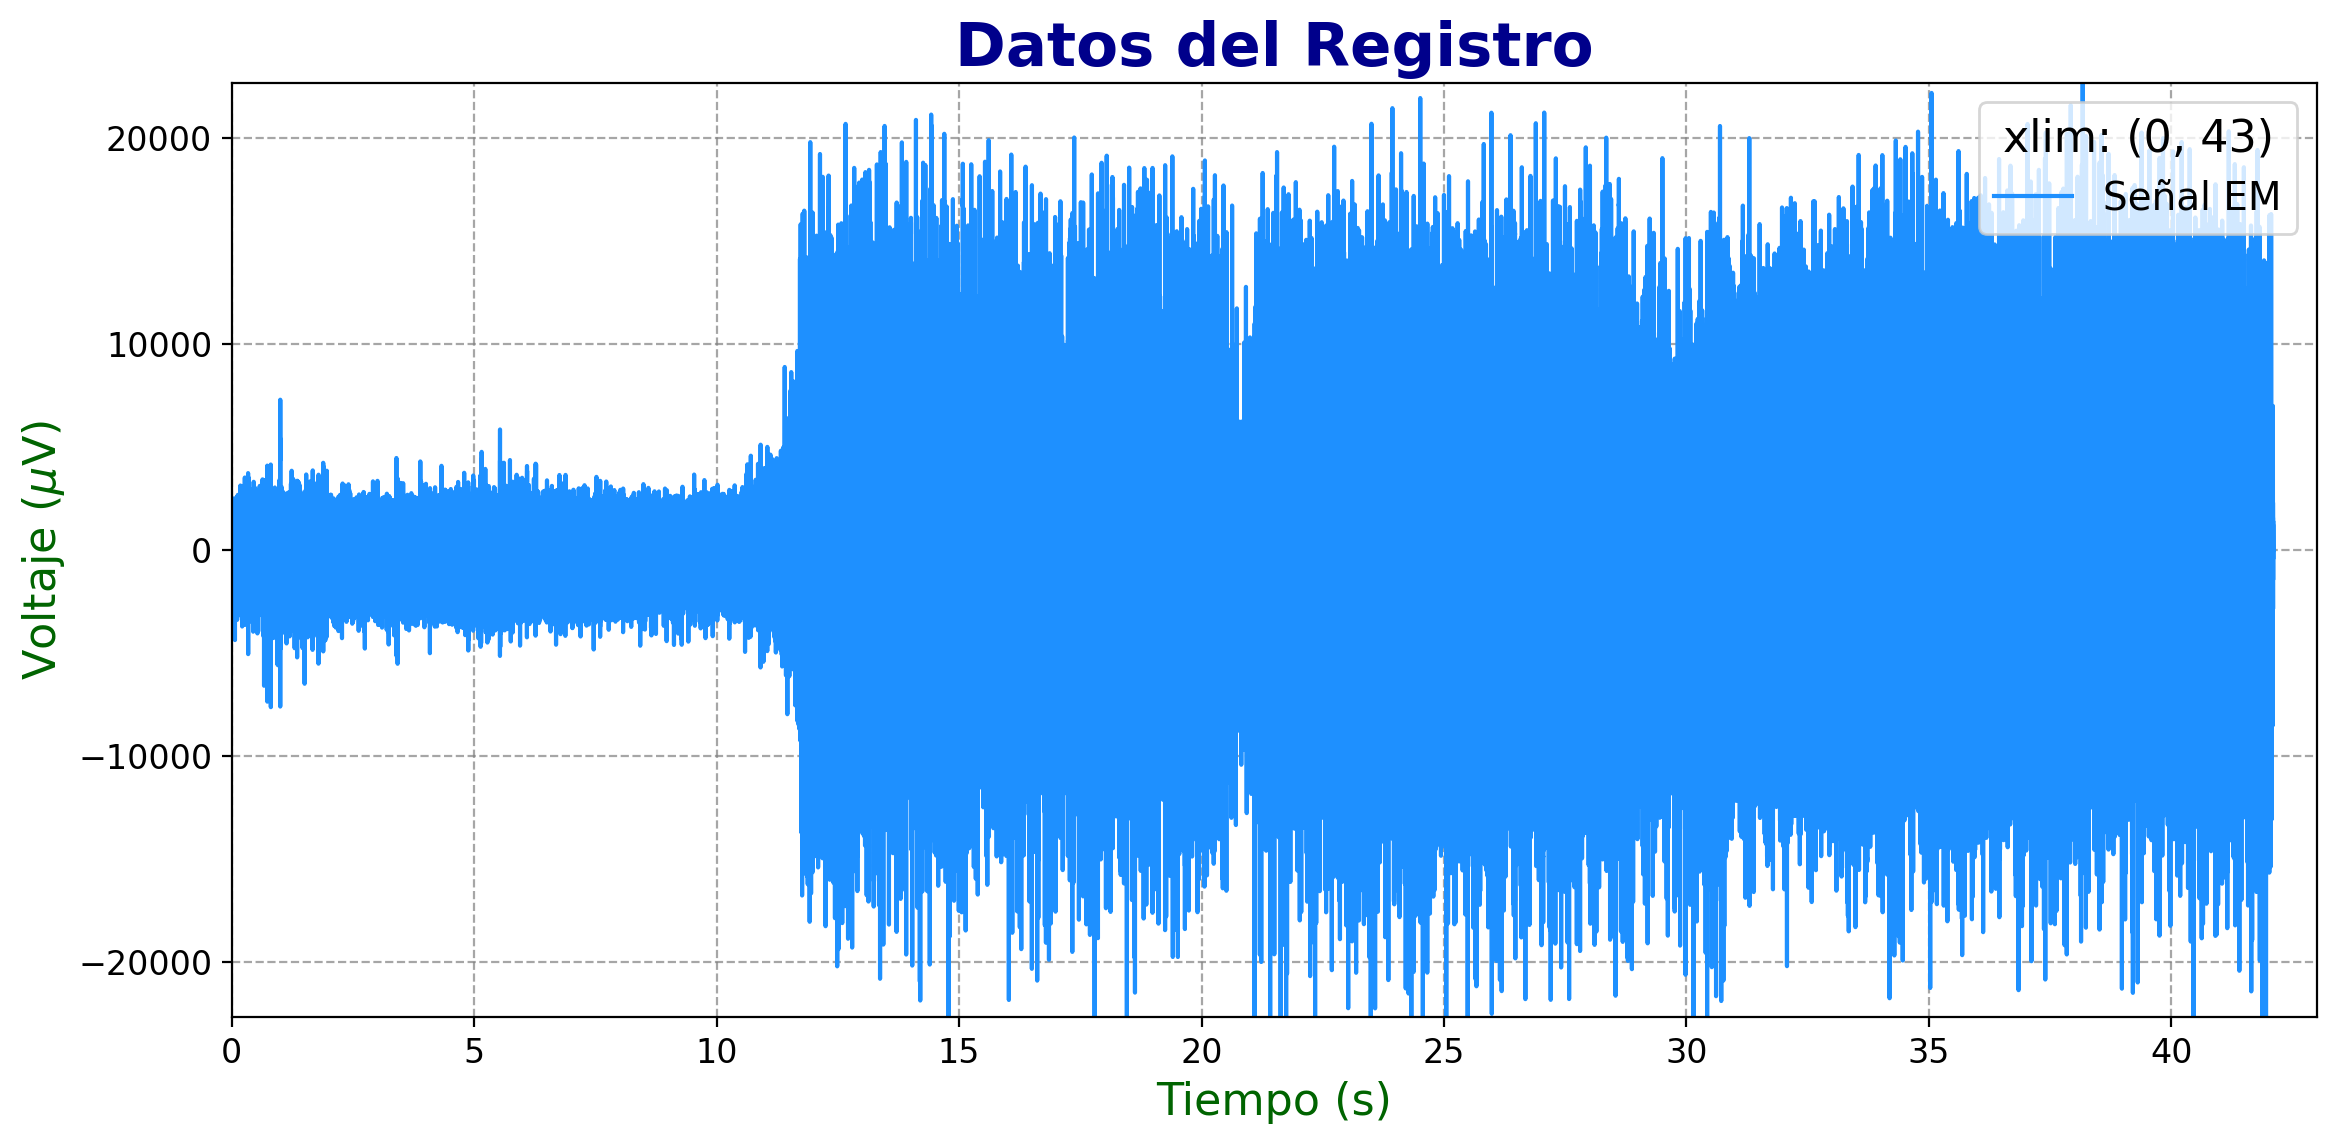

In [11]:
#Visualización del registro
EMG_Ej.visualizar(0,43)